In [1]:
import os
from importlib import reload
import sys
sys.path.insert(
    0, r'C:\Users\richa\GitHub\py_neuromodulation\pyneuromodulation')

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb

from pybv import write_brainvision
import mne
import mne_bids

import start_BIDS
import define_M1
import nm_reader as NM_reader


def get_all_files(path, suffix, get_bids=False, prefix=None, bids_root=None,
                  verbose=False, extension=None):
    """Return all files in all (sub-)directories of path with given suffixes and prefixes (case-insensitive).

    Args:
        path (string)
        suffix (iterable): e.g. ["vhdr", "edf"] or ".json"
        get_bids (boolean): True if BIDS_Path type should be returned instead of string. Default: False
        bids_root (string/path): Path of BIDS root folder. Only required if get_bids=True.
        prefix (iterable): e.g. ["SelfpacedRota", "ButtonPress] (optional)

    Returns:
        filepaths (list of strings or list of BIDS_Path)
    """

    if isinstance(suffix, str):
        suffix = [suffix]
    if isinstance(prefix, str):
        prefix = [prefix]

    filepaths = []
    for root, dirs, files in os.walk(path):
        for file in files:
            for suff in suffix:
                if file.endswith(suff.lower()):
                    if not prefix:
                        filepaths.append(os.path.join(root, file))
                    else:
                        for pref in prefix:
                            if pref.lower() in file.lower():
                                filepaths.append(os.path.join(root, file))

    bids_paths = filepaths
    if get_bids:
        if not bids_root:
            print(
                "Warning: No root folder given. Please pass bids_root parameter to create a complete BIDS_Path object.")
        bids_paths = []
        for filepath in filepaths:
            entities = mne_bids.get_entities_from_fname(filepath)
            try:
                bids_path = mne_bids.BIDSPath(subject=entities["subject"],
                                              session=entities["session"],
                                              task=entities["task"],
                                              run=entities["run"],
                                              acquisition=entities[
                                                  "acquisition"],
                                              suffix=entities["suffix"],
                                              extension=extension,
                                              root=bids_root)
            except ValueError as err:
                print(
                    f"ValueError while creating BIDS_Path object for file {filepath}: {err}")
            else:
                bids_paths.append(bids_path)

    if verbose:
        if not bids_paths:
            print("No corresponding files found.")
        else:
            print('Corresponding files found:')
            for idx, file in enumerate(bids_paths):
                print(idx, ':', os.path.basename(file))

    return bids_paths

In [4]:
root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\PROJECT_motor_onset_results\MotOnsetPred_2021-06-10_compare_norm+classifiers'

beijing_files = get_all_files(
    path=root,
    suffix='.tsv',
    get_bids=False,
    prefix="movement",
    bids_root=root,
    verbose=True,
    extension=None)

Corresponding files found:
0 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lda_results_100ms_diff.tsv
1 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lr_results_100ms_diff.tsv
2 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_svm_lin_results_100ms_diff.tsv
3 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_xgb_results_100ms_diff.tsv
4 : sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lda_results_100ms_diff.tsv
5 : sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lr_results_100ms_diff.tsv
6 : sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_svm_lin_results_100ms_diff.tsv
7 : sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_xgb_results_100ms_diff.tsv
8 : sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_a

In [15]:
deriv_root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives'

berlin_files = get_all_files(
    path=deriv_root,
    suffix='.tsv',
    get_bids=False,
    prefix="group",
    bids_root=deriv_root,
    verbose=True,
    extension=None)

Corresponding files found:
0 : Contralateral_mot_onset_group.tsv
1 : Contralateral_movement_group.tsv
2 : Ipsilateral_mot_onset_group.tsv
3 : Ipsilateral_movement_group.tsv
4 : Contralateral_mot_onset_group.tsv
5 : Contralateral_movement_group.tsv
6 : Ipsilateral_mot_onset_group.tsv
7 : Ipsilateral_movement_group.tsv


In [16]:
group_files = list()
for file in beijing_files + berlin_files:
    if "Contralateral" in file:
        group_files.append(file)
print(*group_files, sep='\n')

C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\Contralateral_mot_onset_group.tsv
C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\Contralateral_movement_group.tsv
C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\Contralateral_mot_onset_group.tsv
C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\Contralateral_movement_group.tsv
C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\Contralateral_mot_onset_group.tsv
C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_deri

# Motor Onset

In [17]:
df_list = list()
for file in group_files[:]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere', 'Recording'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Recording'] = series.index
            if "LFP" in col:
                best_ch = df.loc[:,"LFP_best_ch"].str.slice(stop=-7)
            elif "ECOG" in col:
                best_ch = df.loc[:,"ECOG_best_ch"].str.slice(stop=-13)
            new_df['Normalization'] = 'None' if 'no_norm' in file else '10 sec'
            new_df['Best_Channel'] = best_ch
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

In [18]:
final_df

,Accuracy,Channel,Hemisphere,Recording,Normalization,Best_Channel
sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.559615,Best LFP,Contralateral,sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq...,10 sec,LFP_R_4_3
sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg,0.575833,Best LFP,Contralateral,sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq...,10 sec,LFP_L_3_2
sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.617857,Best LFP,Contralateral,sub-FOG010_ses-EphysMedOff_task-ButtonPress_ac...,10 sec,LFP_R_2_1
sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.566250,Best LFP,Contralateral,sub-FOG013_ses-EphysMedOff_task-ButtonPress_ac...,10 sec,LFP_L_4_1
sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg,0.565385,Best LFP,Contralateral,sub-FOGC001_ses-EphysMedOff_task-ButtonPress_a...,10 sec,LFP_L_2_1
...,...,...,...,...,...,...
sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg,0.934000,Best ECOG,Contralateral,sub-003_ses-EphysMedOff01_task-SelfpacedRotati...,None,ECOG_L_3_
sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg,0.845000,Best ECOG,Contralateral,sub-004_ses-EphysMedOff01_task-SelfpacedRotati...,None,ECOG_L_5_
sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg,0.896667,Best ECOG,Contralateral,sub-004_ses-EphysMedOn01_task-SelfpacedRotatio...,None,ECOG_L_3_
sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg,0.827500,Best ECOG,Contralateral,sub-005_ses-EphysMedOff01_task-SelfpacedRotati...,None,ECOG_R_2_


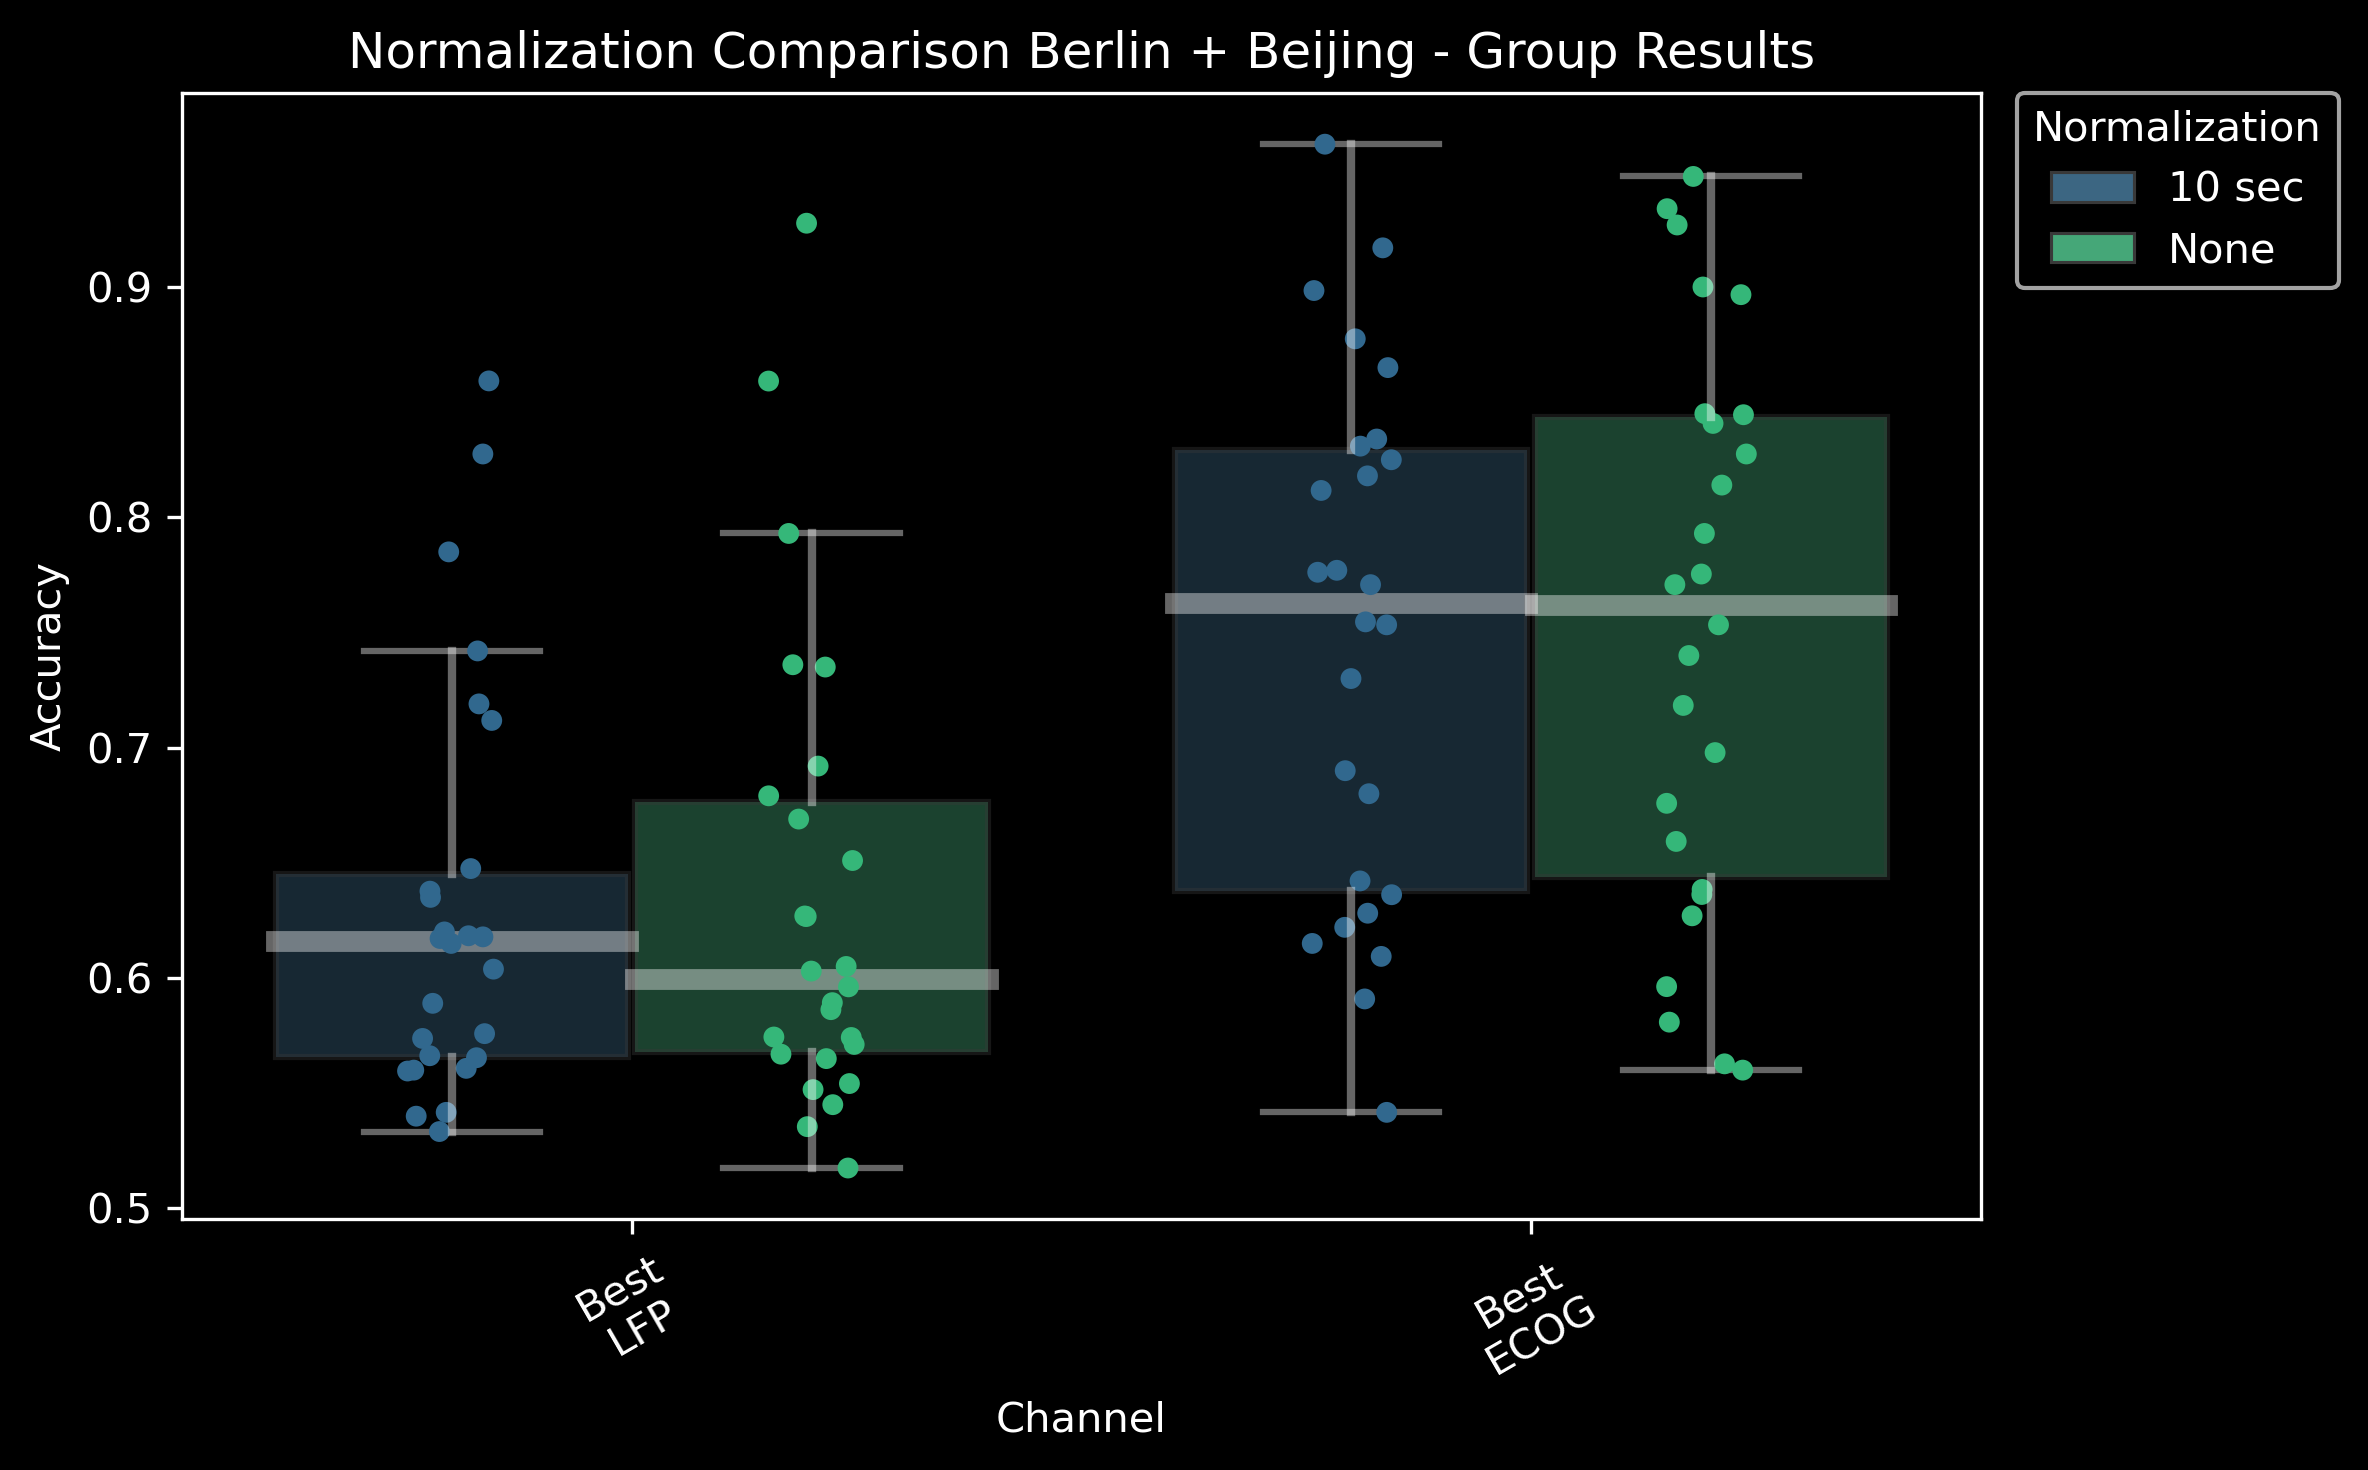

In [26]:
outpath = os.path.join(deriv_root, 'beijing_berlin_class_sLDA_norm_comparison_contralat_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)
order = ["Best LFP", "Best ECOG"]
sb.boxplot(x="Channel", y="Accuracy", hue="Normalization", order=order, 
           data=df, palette="viridis",
           showmeans=False, boxprops=dict(alpha=alpha_box), showcaps=True, showbox=True, 
           showfliers=False, notch=False,
           whiskerprops={'linewidth':2, "zorder":10, "alpha":alpha_box, "color":'white'},
           capprops={"alpha":alpha_box,"color":'white'},
           medianprops=dict(linestyle='-', linewidth=5, color="white", alpha=alpha_box))

ax = sb.stripplot(x="Channel", y="Accuracy", hue="Normalization", order=order, 
                  data=df,palette="viridis", dodge=True, s=5)

plt.xticks(rotation=30)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace(' ','\n') for xtick in xlabels]
ax.set_xticklabels(new_xlabels) 
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)//2], labels[:len(labels)//2], bbox_to_anchor=(1.02, 1), 
               loc=2, borderaxespad=0., title='Normalization')
plt.title("Normalization Comparison Berlin + Beijing - Group Results")
plt.tight_layout()
plt.savefig(outpath)

In [75]:
offsets = [-0.7, -0.2, -0., -2.0, -0.5]

In [103]:
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_file in feature_list[3]
settings = nm_reader.read_settings(feature_file)

# read run_analysis
run_analyzer = nm_reader.read_run_analyzer()

# optionally read ML estimations
ML_est = nm_reader.read_ML_estimations()

df_ = nm_reader.read_M1(feature_file)
features_ = nm_reader.read_features(feature_file)

label = 'EMG_squared'
channels = np.array(settings['ch_names'])
label_name = [ch for ch in channels if label in ch]
dat_label = nm_reader.read_label(label_name[0])

no _ML file computed


In [104]:
features_.columns

Index(['Unnamed: 0', 'ECOG_R_1_SM_HH-avgref_bandpass_activity_theta',
       'ECOG_R_1_SM_HH-avgref_bandpass_mobility_theta',
       'ECOG_R_1_SM_HH-avgref_bandpass_complexity_theta',
       'ECOG_R_1_SM_HH-avgref_bandpass_activity_alpha',
       'ECOG_R_1_SM_HH-avgref_bandpass_mobility_alpha',
       'ECOG_R_1_SM_HH-avgref_bandpass_complexity_alpha',
       'ECOG_R_1_SM_HH-avgref_bandpass_activity_low beta',
       'ECOG_R_1_SM_HH-avgref_bandpass_mobility_low beta',
       'ECOG_R_1_SM_HH-avgref_bandpass_complexity_low beta',
       ...
       'LFP_R_4_3_STN_PI_bandpass_mobility_all gamma',
       'LFP_R_4_3_STN_PI_bandpass_complexity_all gamma',
       'LFP_R_4_3_STN_PI_RawHjorth_Activity',
       'LFP_R_4_3_STN_PI_RawHjorth_Mobility',
       'LFP_R_4_3_STN_PI_RawHjorth_Complexity', 'LFP_R_4_3_STN_PI_raw', 'time',
       'EMG_L_RMS_500', 'EMG_squared', 'MISC_10_TTL'],
      dtype='object', length=453)

In [108]:
import emg

In [107]:
%matplotlib qt
plt.plot(dat_label)
plt.plot(features_['ECOG_R_4_SM_HH-avgref_bandpass_activity_low gamma'])

In [98]:
len(features_)

6374

In [100]:
%matplotlib qt
plt.plot(dat_label)

sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


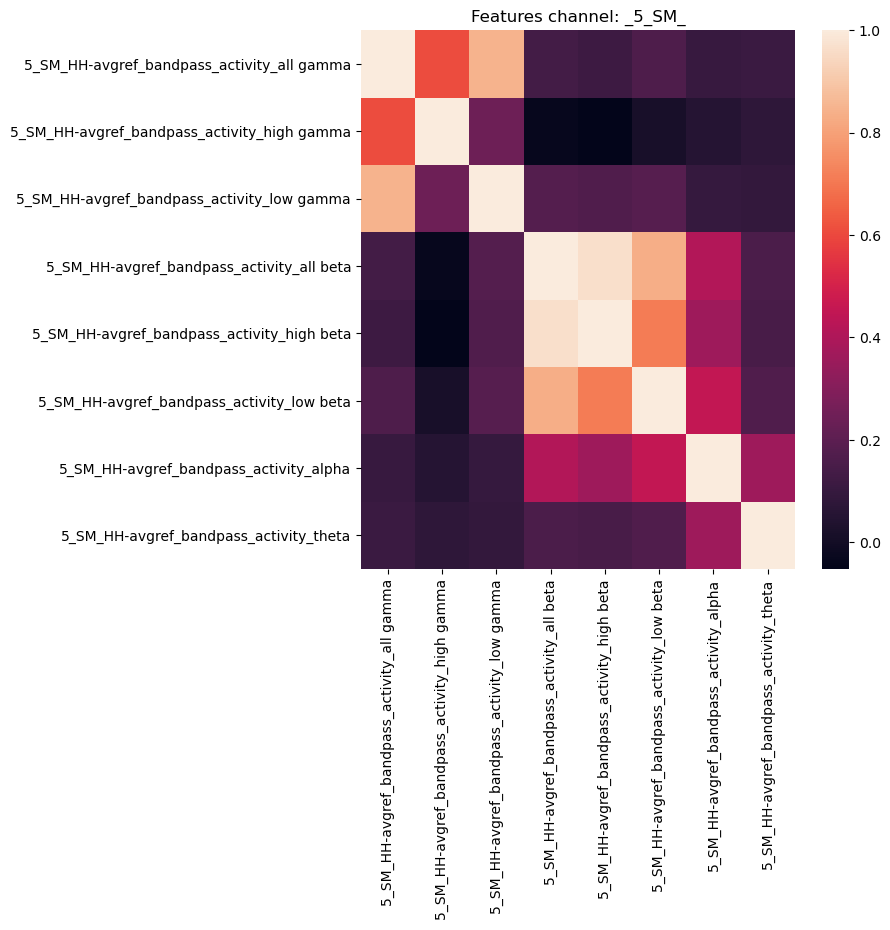

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


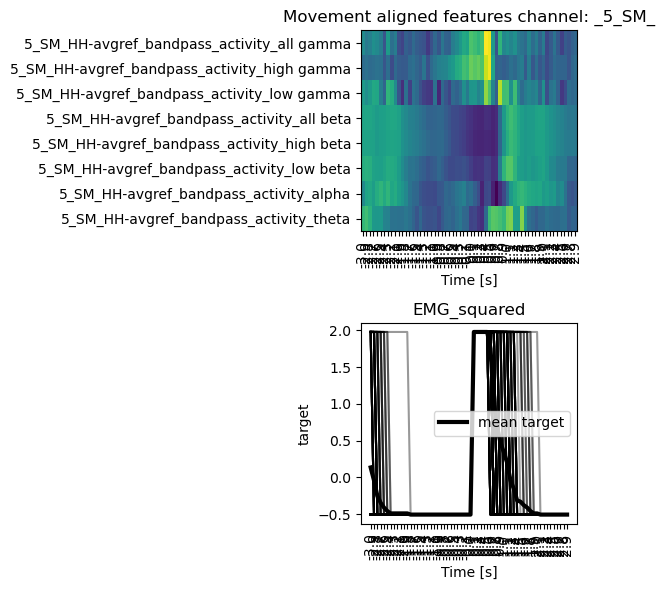

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png
sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


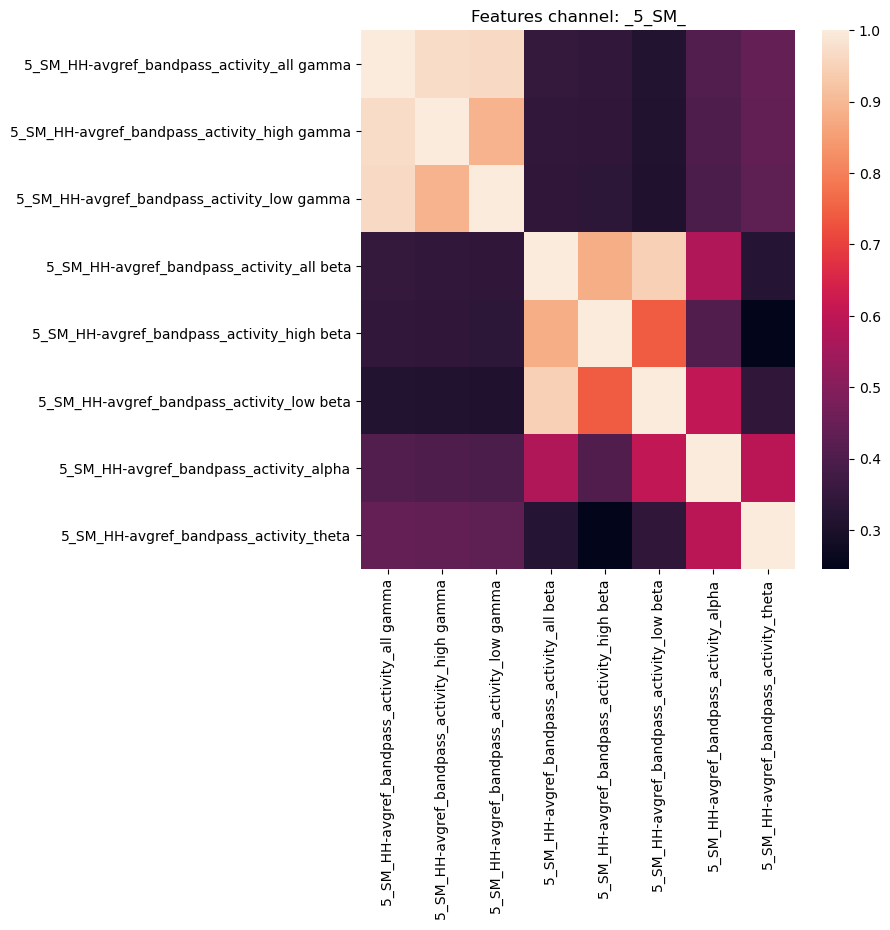

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


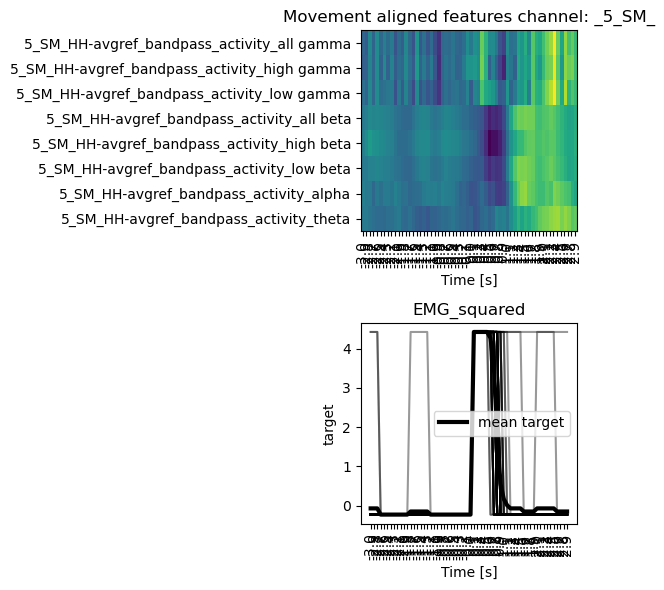

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png
sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


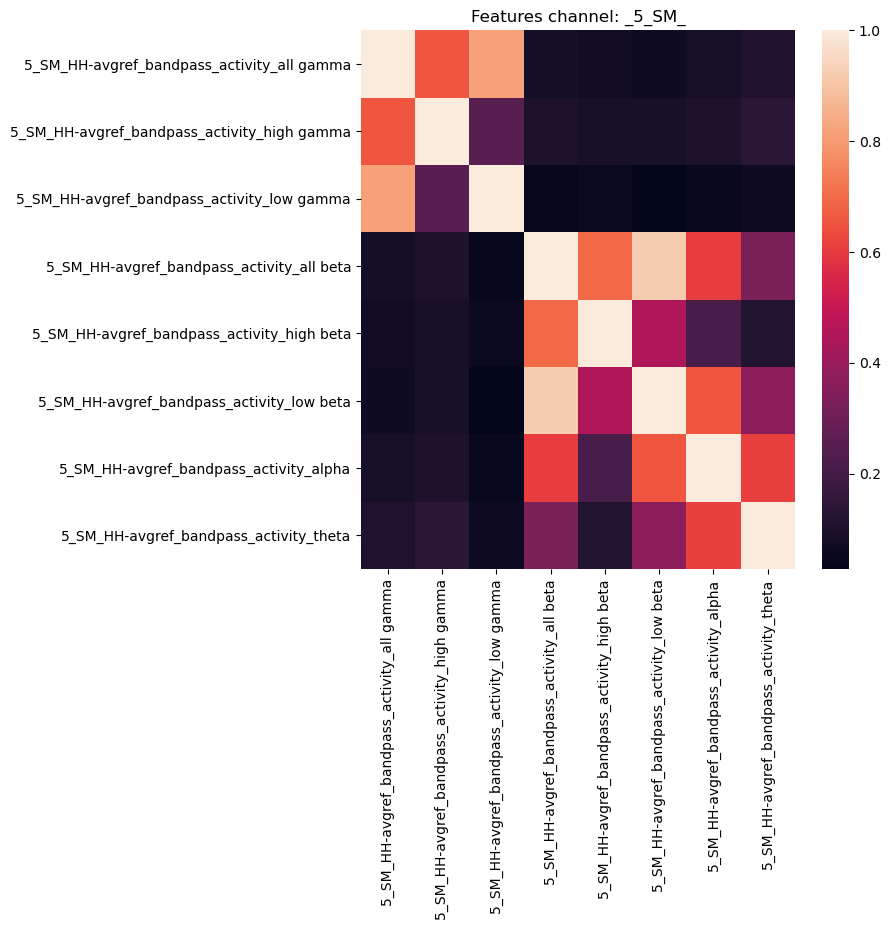

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


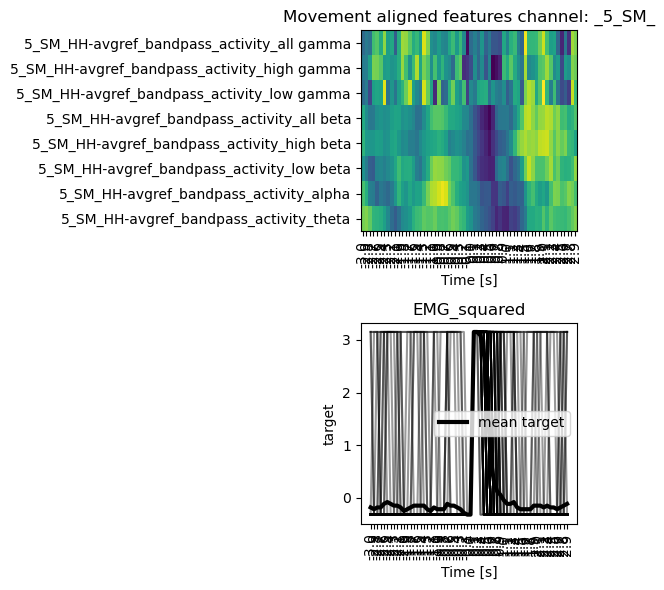

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png
sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


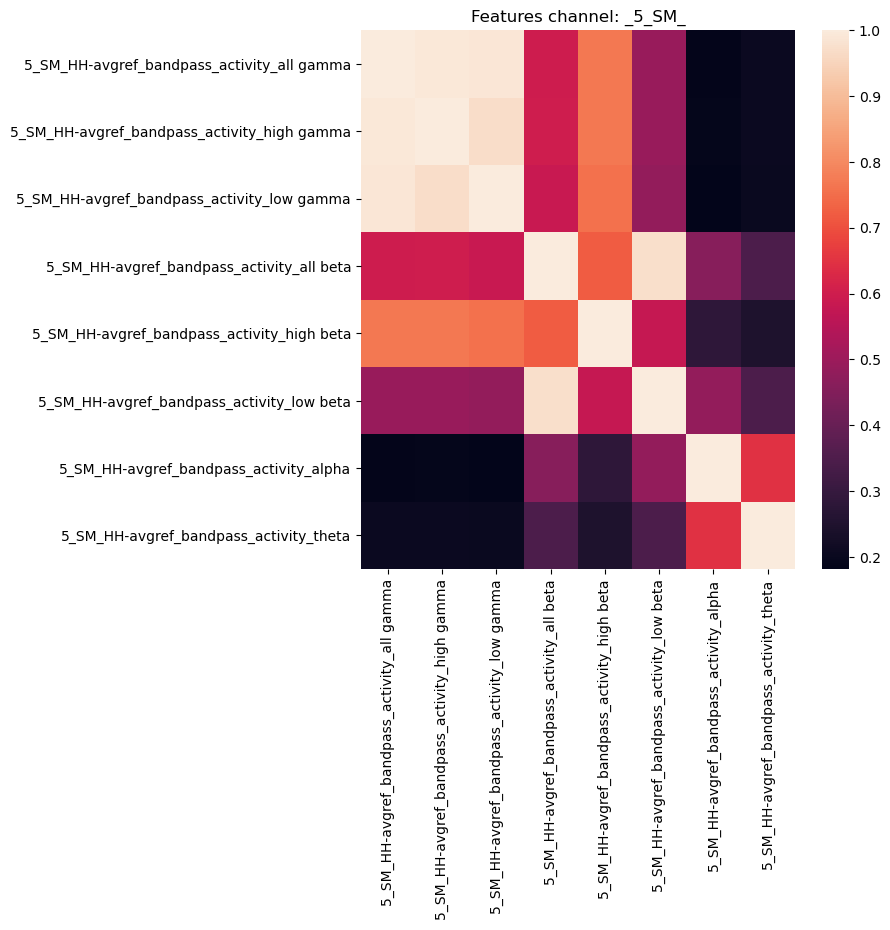

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


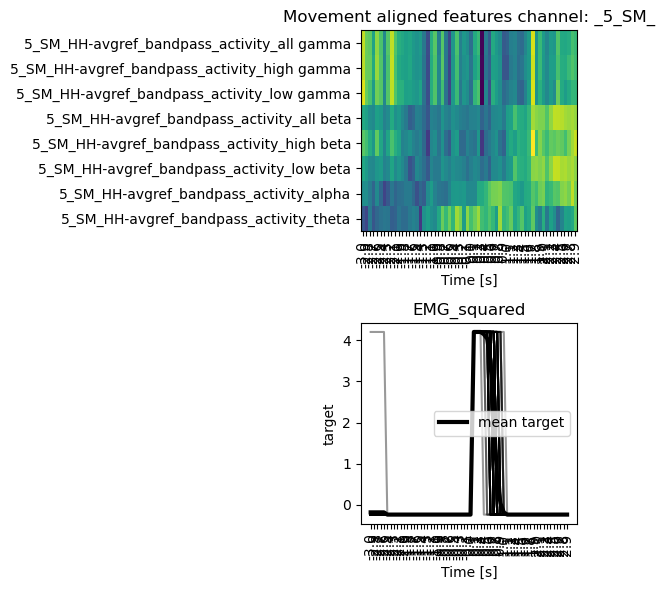

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png
sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature covariance matrix.


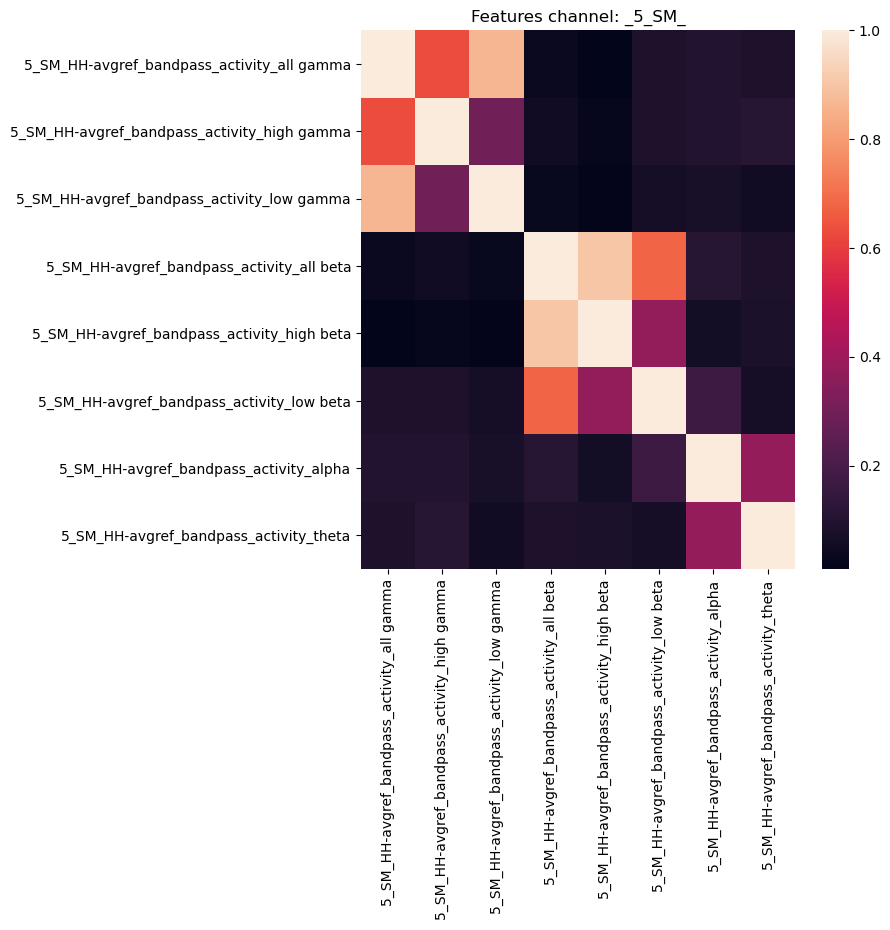

Correlation matrix figure saved to C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\Features_corr_matr_ch__5_SM__bandpass.png
Plotting feature target averaged.


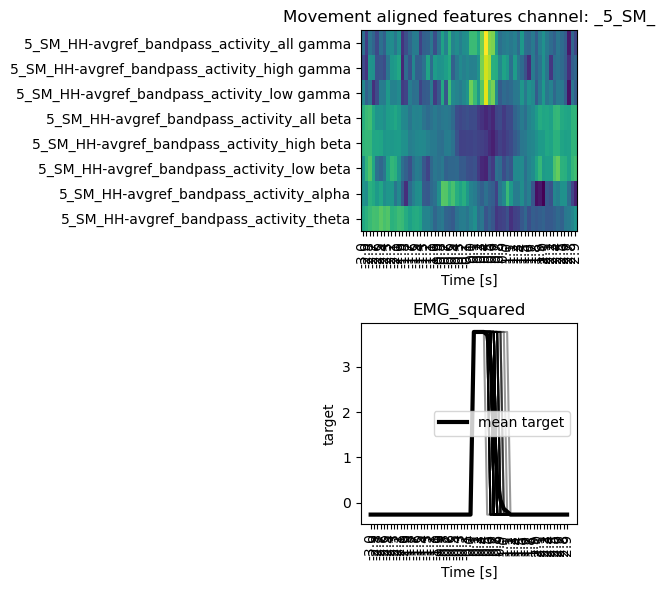

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Beijing_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip\sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__5_SM__bandpass.png


In [41]:
from scipy import stats 

from importlib import reload

reload(NM_reader)

%matplotlib inline
plt.style.use('default')
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_list = nm_reader.get_feature_list()
for feature_file in feature_list[:]:
    print(feature_file)
    run_example_read_features(feature_file, ch_name="_5_SM_", label='EMG_squared')